# IVF Pregnancy Prediction Pipeline

## Overview
- EDA 기반 Feature Engineering
- Data Leakage 방지 전처리
- LightGBM + Optuna 하이퍼파라미터 튜닝
- Top-N 방식 Feature Selection
- OOF 앙상블 (LightGBM + CatBoost)
- Submission 파일 생성

---

## Pipeline
1. 데이터 로드
2. 전처리
3. Feature Engineering (기존 + 논문 기반 파생변수)
4. 빠른 모델 비교 (LGB / CAT)
5. Optuna 하이퍼파라미터 튜닝 (LGBM)
6. Feature Selection (Top-N)
7. OOF 앙상블 (LGB + CAT)
8. 예측 및 제출 파일 생성

In [1]:
# =========================
# 설치
# =========================
!pip install koreanize-matplotlib optuna catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 46.1 MB/s eta 0:00:0000:0100:01


In [2]:
import pandas as pd
import numpy as np

import lightgbm as lgb
from catboost import CatBoostClassifier

import optuna

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.rcParams['axes.unicode_minus'] = False
optuna.logging.set_verbosity(optuna.logging.WARNING)

## 데이터 로드

In [3]:
train = pd.read_csv("/kaggle/input/datasets/mkim98/fertility-dataset/train.csv")
test = pd.read_csv("/kaggle/input/datasets/mkim98/fertility-dataset/test.csv")

TARGET = "임신 성공 여부"
ID_COL = "ID"

print(train.shape, test.shape)
train.head()

(256351, 69) (90067, 68)


,ID,시술 시기 코드,시술 당시 나이,임신 시도 또는 마지막 임신 경과 연수,시술 유형,특정 시술 유형,배란 자극 여부,배란 유도 유형,단일 배아 이식 여부,착상 전 유전 검사 사용 여부,...,기증 배아 사용 여부,대리모 여부,PGD 시술 여부,PGS 시술 여부,난자 채취 경과일,난자 해동 경과일,난자 혼합 경과일,배아 이식 경과일,배아 해동 경과일,임신 성공 여부
0,TRAIN_000000,TRZKPL,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0
1,TRAIN_000001,TRYBLT,만45-50세,NaN,IVF,ICSI,0,알 수 없음,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
2,TRAIN_000002,TRVNRY,만18-34세,NaN,IVF,IVF,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,2.0,NaN,0
3,TRAIN_000003,TRJXFG,만35-37세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
4,TRAIN_000004,TRVNRY,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0


## EDA (분포 + log 확인)

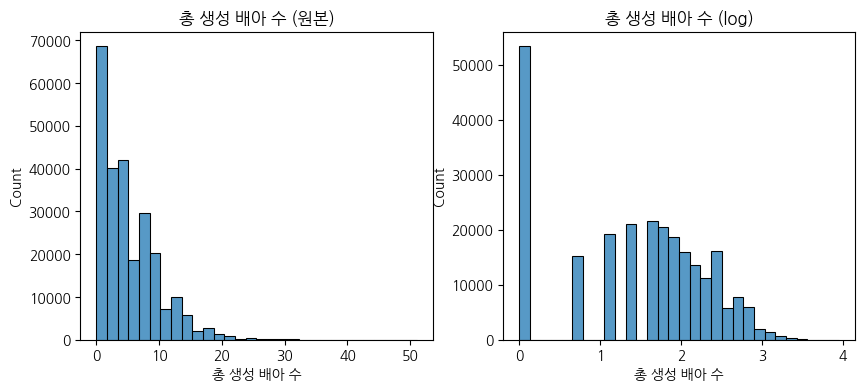

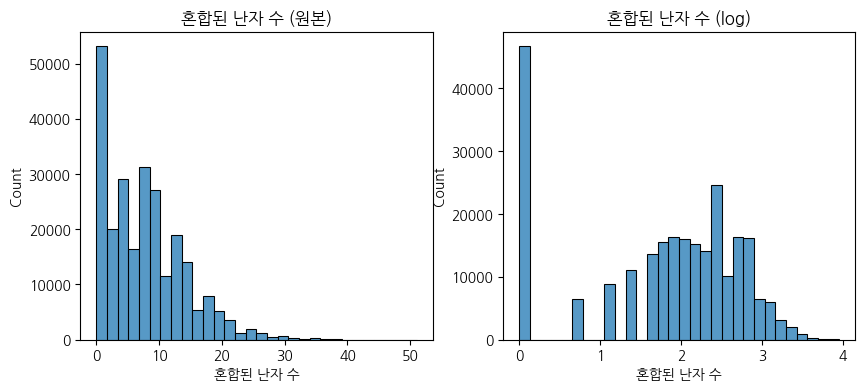

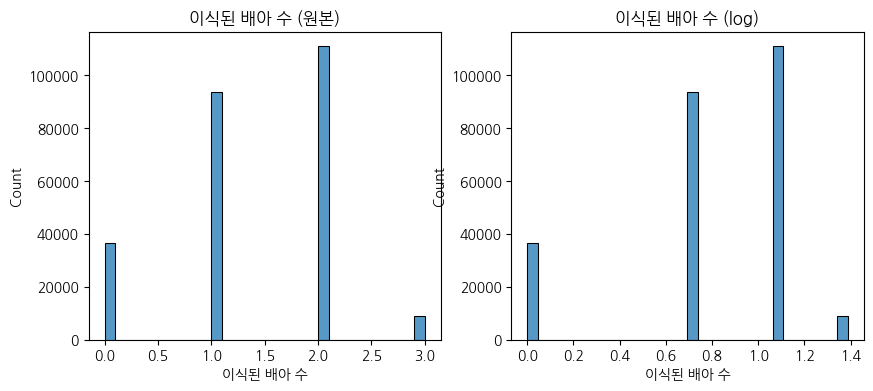

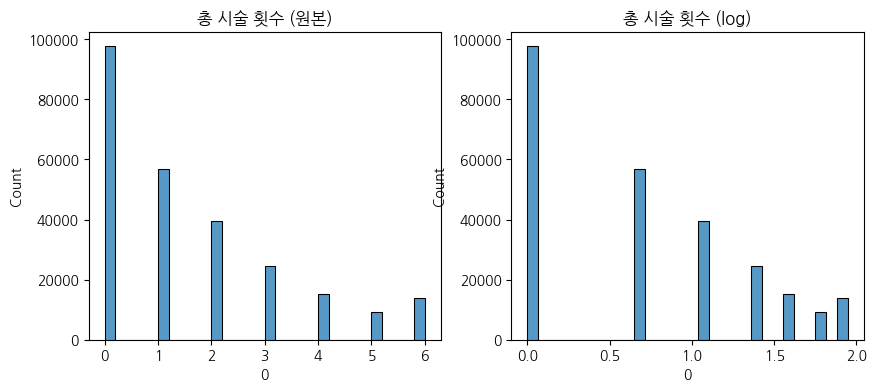

In [4]:
def convert_count(series):
    return (
        series.astype(str)
        .str.extract('(\d+)')[0]
        .astype(float)
    )

num_cols = [
    "총 생성 배아 수",
    "혼합된 난자 수",
    "이식된 배아 수",
    "총 시술 횟수"
]

for col in num_cols:
    if col in train.columns:

        if "횟수" in col:
            tmp = convert_count(train[col])
        else:
            tmp = pd.to_numeric(train[col], errors="coerce")

        plt.figure(figsize=(10,4))

        plt.subplot(1,2,1)
        sns.histplot(tmp, bins=30)
        plt.title(f"{col} (원본)")

        plt.subplot(1,2,2)
        sns.histplot(np.log1p(tmp), bins=30)
        plt.title(f"{col} (log)")

        plt.show()

## Target 관계 확인

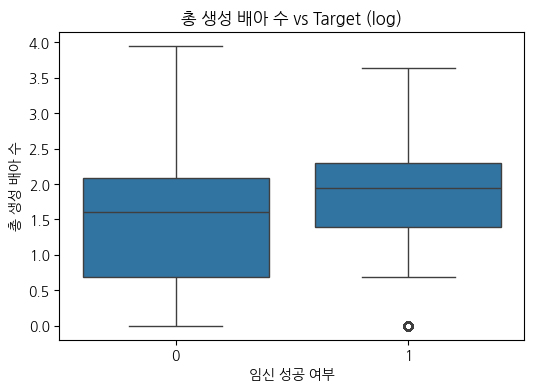

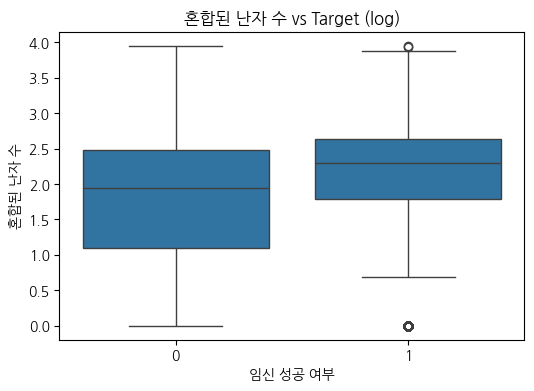

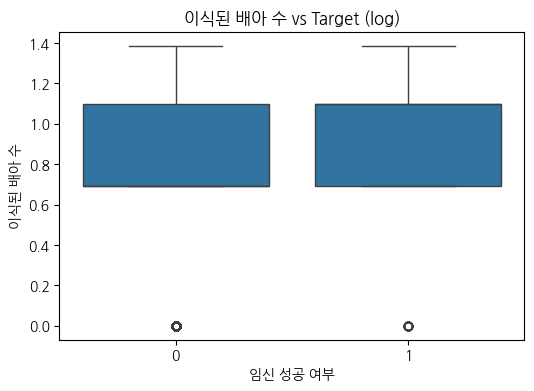

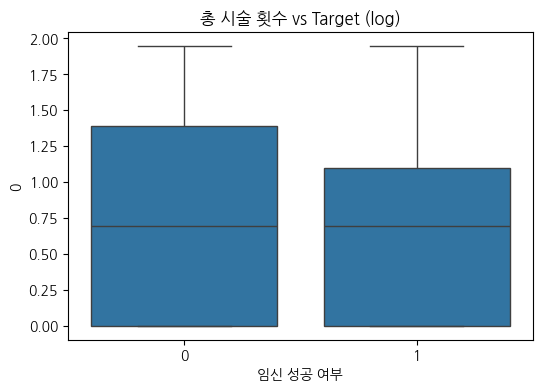

In [5]:
for col in num_cols:
    if col in train.columns:

        if "횟수" in col:
            tmp = convert_count(train[col])
        else:
            tmp = pd.to_numeric(train[col], errors="coerce")

        plt.figure(figsize=(6,4))
        sns.boxplot(x=train[TARGET], y=np.log1p(tmp))
        plt.title(f"{col} vs Target (log)")
        plt.show()

## 전처리 + Feature Engineering

In [6]:
# =========================
# 전처리 함수
# =========================
def drop_columns(df):
    drop_cols = []
    if ID_COL in df.columns:
        drop_cols.append(ID_COL)
    return df.drop(columns=drop_cols, errors="ignore")


def convert_str_to_numeric(df):
    age_map = {
        "만18-34세": 26, "만35-37세": 36, "만38-39세": 38.5,
        "만40-42세": 41, "만43-44세": 43.5, "만45-50세": 47,
        "알 수 없음": np.nan
    }

    if "시술 당시 나이" in df.columns:
        df["시술 당시 나이"] = df["시술 당시 나이"].map(age_map)

    for col in df.columns:
        if "횟수" in col:
            df[col] = convert_count(df[col])

    return df


def handle_missing(df):

    for col in df.select_dtypes(include=["number"]).columns:
        if col != TARGET:
            df[col] = df[col].fillna(df[col].median())

    for col in df.select_dtypes(include=["object"]).columns:
        df[col] = df[col].astype(str).fillna("Unknown")

    return df


def create_features(df):

    base_cols = ["총 생성 배아 수","혼합된 난자 수","이식된 배아 수","총 임신 횟수","총 시술 횟수"]

    for col in base_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    # IVF / DI
    if "시술 유형" in df.columns:
        df["is_ivf"] = (df["시술 유형"] == 0).astype(int)
        df["is_di"] = (df["시술 유형"] == 1).astype(int)

    # log
    for col in ["총 생성 배아 수","혼합된 난자 수","이식된 배아 수"]:
        if col in df.columns:
            df[f"{col}_log"] = np.log1p(df[col])

    # 핵심 feature
    df["배아_생성_효율"] = df["총 생성 배아 수"]/(df["혼합된 난자 수"]+1)
    df["이식_효율"] = df["이식된 배아 수"]/(df["총 생성 배아 수"]+1)
    df["임신_성공률"] = df["총 임신 횟수"]/(df["총 시술 횟수"]+1)

    df["난자당_배아"] = df["총 생성 배아 수"]/(df["혼합된 난자 수"]+1)
    df["이식당_임신"] = df["총 임신 횟수"]/(df["이식된 배아 수"]+1)

    df["실패_횟수"] = df["총 시술 횟수"] - df["총 임신 횟수"]
    df["실패율"] = df["실패_횟수"]/(df["총 시술 횟수"]+1)

    if "시술 당시 나이" in df.columns:
        df["배아_품질"] = df["총 생성 배아 수"]/(df["시술 당시 나이"]+1)
        df["고령"] = (df["시술 당시 나이"]>=38).astype(int)

    df["경험지수"] = df["총 시술 횟수"] * df["임신_성공률"]

    df["ivf_효율"] = df["배아_생성_효율"] * df["이식_효율"] * df.get("is_ivf",0)

    return df


def encode_categorical(train_df, test_df):

    cat_cols = train_df.select_dtypes(include=["object"]).columns

    for col in cat_cols:
        if col == TARGET:
            continue

        le = LabelEncoder()
        train_df[col] = le.fit_transform(train_df[col].astype(str))

        mapping = {k:v for v,k in enumerate(le.classes_)}
        test_df[col] = test_df[col].astype(str).map(mapping).fillna(-1).astype(int)

    return train_df, test_df


def preprocess(train, test):

    train = drop_columns(train)
    test = drop_columns(test)

    train = convert_str_to_numeric(train)
    test = convert_str_to_numeric(test)

    train = handle_missing(train)
    test = handle_missing(test)

    train = create_features(train)
    test = create_features(test)

    train, test = encode_categorical(train, test)

    return train, test

## 전처리 실행

In [7]:
train_df, test_df = preprocess(train, test)

X = train_df.drop(columns=[TARGET])
y = train_df[TARGET]

print(X.shape)

(256351, 83)


## 빠른 모델 비교

In [8]:
def quick_cv(model, name):
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for tr_idx, val_idx in skf.split(X, y):

        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        if name == "LGB":
            model.fit(
                X_tr, y_tr,
                eval_set=[(X_val, y_val)],
                callbacks=[lgb.early_stopping(30, verbose=False)]
            )

        elif name == "CAT":
            model.fit(
                X_tr, y_tr,
                eval_set=(X_val, y_val),
                verbose=0
            )

        preds = model.predict_proba(X_val)[:, 1]
        scores.append(roc_auc_score(y_val, preds))

    return np.mean(scores)


print("LGB:", quick_cv(lgb.LGBMClassifier(n_estimators=500, verbosity=-1), "LGB"))
print("CAT:", quick_cv(CatBoostClassifier(iterations=500, verbose=0), "CAT"))

LGB: 0.7387069418369836
CAT: 0.7388960578150936


## Optuna (LGBM)

In [9]:
def objective(trial):

    params = {
        "objective":"binary",
        "metric":"auc",
        "verbosity":-1,
        "n_jobs":-1,
    
        "n_estimators":trial.suggest_int("n_estimators",800,2000),
        "learning_rate":trial.suggest_float("learning_rate",0.01,0.05),
    
        "num_leaves":trial.suggest_int("num_leaves",31,256),
        "max_depth":trial.suggest_int("max_depth",4,12),
        "min_child_samples":trial.suggest_int("min_child_samples",10,100),
    
        "subsample":trial.suggest_float("subsample",0.7,1.0),
        "colsample_bytree":trial.suggest_float("colsample_bytree",0.7,1.0),
    
        "reg_alpha":trial.suggest_float("reg_alpha",0.0,5.0),
        "reg_lambda":trial.suggest_float("reg_lambda",0.0,5.0),
    }

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    aucs = []

    for tr_idx, val_idx in skf.split(X,y):
        model = lgb.LGBMClassifier(**params)

        model.fit(
            X.iloc[tr_idx], y.iloc[tr_idx],
            eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],
            callbacks=[lgb.early_stopping(50, verbose=False)]
        )

        preds = model.predict_proba(X.iloc[val_idx])[:,1]
        aucs.append(roc_auc_score(y.iloc[val_idx], preds))

    return np.mean(aucs)


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=60)

print("Best:", study.best_params)

Best: {'n_estimators': 1384, 'learning_rate': 0.03619751604654644, 'num_leaves': 184, 'max_depth': 5, 'min_child_samples': 63, 'subsample': 0.7182096191906608, 'colsample_bytree': 0.7574371718696333, 'reg_alpha': 4.172838205460451, 'reg_lambda': 4.302587637784979}


## CV 점수

In [10]:
cv_scores = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for tr_idx, val_idx in skf.split(X, y):
    model = lgb.LGBMClassifier(**study.best_params)

    model.fit(
        X.iloc[tr_idx], y.iloc[tr_idx],
        eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )

    preds = model.predict_proba(
        X.iloc[val_idx],
        num_iteration=model.best_iteration_
    )[:, 1]

    cv_scores.append(roc_auc_score(y.iloc[val_idx], preds))

print("CV Scores:", cv_scores)
print("Mean CV:", np.mean(cv_scores))

CV Scores: [np.float64(0.7379286297636105), np.float64(0.742878192284238), np.float64(0.7397096106875704), np.float64(0.7379385919281921), np.float64(0.7409933520137587)]
Mean CV: 0.7398896753354739


## Feature Importance

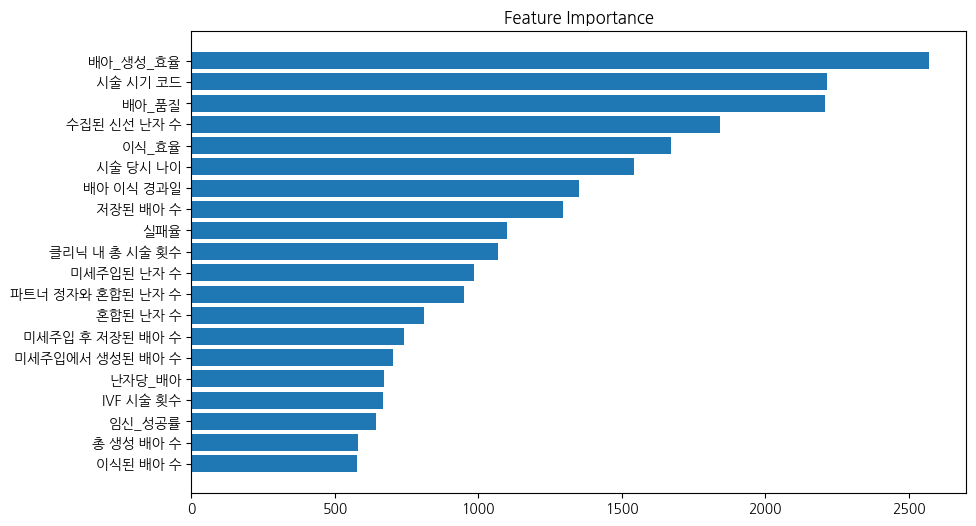

In [11]:
best_model = lgb.LGBMClassifier(**study.best_params)
best_model.fit(X, y)

feat_imp = pd.DataFrame({
    "feature":X.columns,
    "importance":best_model.feature_importances_
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feat_imp["feature"].head(20), feat_imp["importance"].head(20))
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

## Feature Selection (Top-N)

In [12]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

topn_results = {}

for n in [120,100,80,60,50]:
    top_features = feat_imp.head(n)["feature"].tolist()
    X_tmp = X[top_features]

    scores = []

    for tr_idx, val_idx in skf.split(X_tmp,y):
        model = lgb.LGBMClassifier(**study.best_params)
        model.fit(
            X_tmp.iloc[tr_idx], y.iloc[tr_idx],
            eval_set=[(X_tmp.iloc[val_idx], y.iloc[val_idx])],
            callbacks=[lgb.early_stopping(50, verbose=False)]
        )

        preds = model.predict_proba(
            X_tmp.iloc[val_idx],
            num_iteration=model.best_iteration_
        )[:,1]
        scores.append(roc_auc_score(y.iloc[val_idx], preds))

    topn_results[n] = np.mean(scores)
    print(f"Top {n}:", topn_results[n])

best_n = max(topn_results, key=topn_results.get)
print("Best N:", best_n)

Top 120: 0.7399261341808432
Top 100: 0.7399261341808432
Top 80: 0.7399261341808432
Top 60: 0.7398475409535215
Top 50: 0.7398515324964674
Best N: 120


## 최종 Feature 적용

In [13]:
top_features = feat_imp.head(best_n)["feature"].tolist()

X_final = X[top_features]
test_final = test_df[top_features]

print("최종 feature 수:", len(top_features))

최종 feature 수: 83


## OOF 앙상블

In [14]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_lgb = np.zeros(len(X_final))
oof_cat = np.zeros(len(X_final))

test_lgb = np.zeros(len(test_final))
test_cat = np.zeros(len(test_final))

for tr_idx, val_idx in skf.split(X_final,y):

    X_tr, X_val = X_final.iloc[tr_idx], X_final.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    lgb_model = lgb.LGBMClassifier(**study.best_params)
    lgb_model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )

    cat_model = CatBoostClassifier(
        iterations=1500,
        learning_rate=0.03,
        depth=6,
        eval_metric="AUC",
        task_type="GPU",
        verbose=0
    )
    cat_model.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        early_stopping_rounds=50,
        verbose=0
    )

    oof_lgb[val_idx] = lgb_model.predict_proba(
        X_val,
        num_iteration=lgb_model.best_iteration_
    )[:,1]
    
    oof_cat[val_idx] = cat_model.predict_proba(X_val)[:,1]
    
    test_lgb += lgb_model.predict_proba(
        test_final,
        num_iteration=lgb_model.best_iteration_
    )[:,1] / skf.n_splits
    
    test_cat += cat_model.predict_proba(test_final)[:,1] / skf.n_splits

Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


## Weight 자동 탐색

In [1]:
best_score = 0
best_w = 0

for w in np.arange(0,1.01,0.05):
    pred = w*oof_lgb + (1-w)*oof_cat
    score = roc_auc_score(y, pred)

    if score > best_score:
        best_score = score
        best_w = w

    print(f"{w:.2f} → {score:.5f}")

print("Best weight:", best_w)

NameError: name 'np' is not defined

## 예측 및 제출 파일 생성

In [16]:
final_preds = best_w * test_lgb + (1-best_w) * test_cat

submission = pd.DataFrame({
    "ID": test["ID"],
    "probability": final_preds
})

submission.to_csv("submission_final.csv", index=False)

print("✅ 완료")

✅ 완료
